# Lab 3: Linear and logistic regression
Import and explore the data, implements python functions to (i) learn linear regression models and (ii) learn logistic regression models. Submit this notebook to eclass with the name "lab3_123456.ipynb" and replace "123456" by the ID you used for the first lab.

In [409]:
import numpy as np
import pandas as pd
from sklearn import model_selection
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

Import the data in "housing.txt", "occupacy_training_set.csv", "occupacy_test_set_1.csv" and "occupacy_test_set_2.csv" datasets

In [410]:
## housing -> linear
columns = ["CRIM" , "ZN", "INDUS" , "CHAS" , "NOX" , "RM" , "AGE" , "DIS" , "RAD" , "TAX" , "PTRATIO" , "B", "LSTAT", "MEDV"]
with open("housing.txt", "r") as f:
    lines = f.readlines()

data = [list(map(float, line.strip().split())) for line in lines]
df_housing = pd.DataFrame(data, columns=columns)

X_housing = df_housing[["CRIM" , "ZN", "INDUS" , "CHAS" , "RM" , "AGE" , "DIS" , "RAD" , "TAX" , "PTRATIO" , "B", "LSTAT"]]
y_housing = df_housing[["MEDV"]]


In [411]:
X_housing

,CRIM,ZN,INDUS,CHAS,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0.0,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.0,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.0,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.0,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0.0,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33
...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,6.593,69.1,2.4786,1.0,273.0,21.0,391.99,9.67
502,0.04527,0.0,11.93,0.0,6.120,76.7,2.2875,1.0,273.0,21.0,396.90,9.08
503,0.06076,0.0,11.93,0.0,6.976,91.0,2.1675,1.0,273.0,21.0,396.90,5.64
504,0.10959,0.0,11.93,0.0,6.794,89.3,2.3889,1.0,273.0,21.0,393.45,6.48


Divide your dataset into training and testing sets (occupacy is already separated, choose one of the test sets as validation set)

In [412]:
# occupacy -> logistica
doccupacy_training = pd.read_csv("occupancy_training_set.csv")
doccupacy_test1 = pd.read_csv("occupancy_test_set_1.csv")
doccupacy_test2 = pd.read_csv("occupancy_test_set_2.csv")

Check the scale of the values of housing features. TIP: consider normalizing your dataset.

In [413]:
# Standar normalization
# x_norm = x - u / σ 

def standar_norm(X):
    X_mean = np.mean(X, axis=0)
    X_std = np.std(X, axis=0)
    X_norm = (X - X_mean) / X_std
    return X_norm

# Min-Max scaling
# x_norm = x - xmin / xmax - xmin
def min_max_scaling(X):
    X_min = np.min(X, axis=0)
    X_max = np.max(X, axis=0)
    X_norm = (X - X_min) / (X_max - X_min)
    return X_norm

In [414]:
X_housing_standar = standar_norm(X_housing)
X_housing_standar

,CRIM,ZN,INDUS,CHAS,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,-0.419782,0.284830,-1.287909,-0.272599,0.413672,-0.120013,0.140214,-0.982843,-0.666608,-1.459000,0.441052,-1.075562
1,-0.417339,-0.487722,-0.593381,-0.272599,0.194274,0.367166,0.557160,-0.867883,-0.987329,-0.303094,0.441052,-0.492439
2,-0.417342,-0.487722,-0.593381,-0.272599,1.282714,-0.265812,0.557160,-0.867883,-0.987329,-0.303094,0.396427,-1.208727
3,-0.416750,-0.487722,-1.306878,-0.272599,1.016303,-0.809889,1.077737,-0.752922,-1.106115,0.113032,0.416163,-1.361517
4,-0.412482,-0.487722,-1.306878,-0.272599,1.228577,-0.511180,1.077737,-0.752922,-1.106115,0.113032,0.441052,-1.026501
...,...,...,...,...,...,...,...,...,...,...,...,...
501,-0.413229,-0.487722,0.115738,-0.272599,0.439316,0.018673,-0.625796,-0.982843,-0.803212,1.176466,0.387217,-0.418147
502,-0.415249,-0.487722,0.115738,-0.272599,-0.234548,0.288933,-0.716639,-0.982843,-0.803212,1.176466,0.441052,-0.500850
503,-0.413447,-0.487722,0.115738,-0.272599,0.984960,0.797449,-0.773684,-0.982843,-0.803212,1.176466,0.441052,-0.983048
504,-0.407764,-0.487722,0.115738,-0.272599,0.725672,0.736996,-0.668437,-0.982843,-0.803212,1.176466,0.403225,-0.865302


Create a function that estimate the parameters of a linear regression model using the closed form solution to fit the data.

In [415]:
# phi = (phi^T * phi)^-1 * phi^T * y
def LiR_c(Xtrain,ytrain):
    #Xtrain_b = np.c_[np.ones((Xtrain.shape[0], 1)), Xtrain]
    Xtrain = np.asarray(Xtrain)
    w = np.linalg.inv(Xtrain.T @ Xtrain) @ Xtrain.T @ ytrain
    return w

Create a function that estimate the parameters of a linear regression model using stochastic gradient descent iterative procedure. Your function should output a vector containing the value of the loss at each gradient update besides the linear regression model parameters.

In [416]:
#w(t+1) = w(t) - η(tn - w(t)T xn)xn
def LiR_gd(Xtrain,ytrain,learning_rate,max_it):
    # Transform data to numpy arrays
    # And reshape ytrain to be a column vector
    Xtrain = np.array(Xtrain)
    ytrain = np.array(ytrain).reshape(-1, 1)
    n_samples, n_features = Xtrain.shape    
    
    # Initialize weights and loss history
    w = np.zeros((n_features, 1))
    loss_history = []

    ## Iterate over the number of iterations
    for i in range(max_it):
        total_loss = 0
        # Iterate over each sample
        # And update the weights
        for n in range(n_samples):
            x_n = Xtrain[n].reshape(1, n_features)
            t_n = ytrain[n].reshape(1, 1)

            # Prediction: w^T * phi_n = x_n @ w (1xfeatures * featuresx1 = 1x1)
            y_pred = np.dot(x_n, w)  # This is w^T * phi_n

            # loss = y_pred - y_n
            loss = t_n - y_pred

            # w = w + η(tn - w(t)T xn)xn
            w = w + learning_rate * loss * x_n.T
            total_loss += (loss ** 2).item()
        loss_history.append(total_loss / n_samples)

    return w, loss_history

Train two linear regression models using your training set of the housing dataset, the parameters of one model using the closed form solution  and the parameters of the second model using the stochastic gradient descent procedure. Print the parameters for both procedures and plot the loss at each parameter update.

In [417]:
X_train_housing, X_test_housing, y_train_housing, y_test_housing = model_selection.train_test_split(X_housing_standar, y_housing, test_size=0.33, random_state=42)

w_lir_c = LiR_c(X_train_housing, y_train_housing)
w_lir_gd, loss = LiR_gd(X_train_housing, y_train_housing, 0.001, 10)

Build a function that uses the learned parameters w to predict the value (MEDV in our dataset) for new datapoints.

In [418]:
def predLiR(w,Xtest):
    Xtest = np.asarray(Xtest)
    preds = Xtest @ w
    
    return preds

Use your trained parameters of linear regression and your predLiR() function to predict for your test set of the housing dataset

In [419]:
y_pred = predLiR(w_lir_c, X_test_housing)
y_pred

,MEDV
0,5.802608
1,13.815213
2,-3.564077
3,0.685897
4,-1.113044
...,...
162,-3.839775
163,0.590628
164,8.026021
165,-3.757387


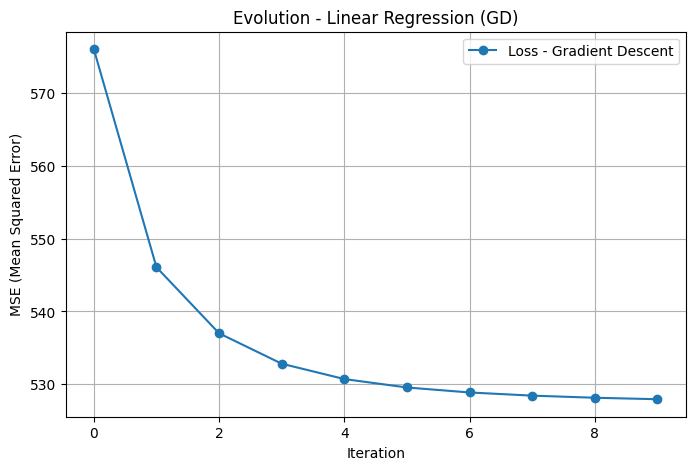

In [420]:
plt.figure(figsize=(8, 5))
plt.plot(loss, marker='o', label='Loss - Gradient Descent')
plt.title('Evolution - Linear Regression (GD)')
plt.xlabel('Iteration')
plt.ylabel('MSE (Mean Squared Error)')
plt.grid(True)
plt.legend()
plt.show()

Evaluate your predictions using the Root Mean Square Error. 

In [421]:
def rmse(y_pred, y_test):
    y_true = np.array(y_test).reshape(-1)
    y_pred = np.array(y_pred).reshape(-1)
    mse = np.mean((y_true - y_pred) ** 2)
    rmse = np.sqrt(mse)
    return rmse

rsme_result = rmse(y_pred, y_test_housing)
print(rsme_result)

24.035986396434605


Build a function that learns the parameters of a logistic regression model given a dataset using a stochastic gradient descent strategy. The function should output a vector wih the loss values during training.

In [422]:
# gradient E(w) = sum(yn -tn) * phi_n)
# where yn = w^T * phi_n

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def LoR_gd(Xtrain,ytrain,learning_rate,max_it):
    print("Logistic Regression - Gradient Descent")
    n_samples, n_features = Xtrain.shape    
    w =   np.zeros((n_features, 1))
    loss = []

    for i in range(max_it):
        z = np.dot(Xtrain, w)
        y_pred = sigmoid(z)

        # Gradient = sum((yn - tn) * phi_n)
        error = y_pred - ytrain
        gradient = np.dot(Xtrain.T, error)

        # Update weights
        w = w - learning_rate * gradient

        # Compute loss
        # -sum(tn lnyn + (1-tn) ln(1-yn))
        epsilon = 1e-15
        cross_entropy_loss = -np.sum(ytrain * np.log(y_pred + epsilon) + (1 - ytrain) * np.log(1 - y_pred + epsilon))
        loss.append(cross_entropy_loss)

    print("Final Logistic Regression - Gradient Descent")
    return w, loss

Build a function that learns the parameters of a logistic regression model given a dataset using the reweighted least squares algorithm. The function should output a vector wih the loss values during training.

In [423]:
# w(new) = (phi^T * R * phi)^-1 phi^T * Rz
# where z = phi * w(old) - R^-1 (y-t)
def LoR_2(Xtrain,ytrain, max_it, learning_rate = 0.01):
    print("Logistic Regression - Reweighted Least Squares")
    Xtrain = np.array(Xtrain)
    ytrain = np.array(ytrain).reshape(-1, 1)
    n_samples, n_features = Xtrain.shape    
    w =   np.zeros((n_features, 1))
    loss = []

    for i in range(max_it):
        y = Xtrain @ w
        #  Compute the predictions
        t = sigmoid(y)

        # Compute the diagonal weight matrix R
        #R = np.diag((t * (1 - t)).flatten())}
        R = (t * (1 - t)).flatten()

        # Compute z vector
        #z = y - np.linalg.pinv(R) @ (t - ytrain)
        # I am choosing to use this method because it is more numerically stable and with other method it is slow
        z = y - (t - ytrain) / (R[:, np.newaxis] + 1e-8)

        # Update rule for w using weighted least squares
        XT_R = Xtrain.T * R
        H = XT_R @ Xtrain
        H_inv = np.linalg.inv(H)

        w = H_inv @ XT_R @ z

        # Compute loss
        # -sum(tn lnyn + (1-tn) ln(1-yn))
        epsilon = 1e-15  # for numerical stability
        log_loss = -np.sum(ytrain * np.log(t + epsilon) + (1 - ytrain) * np.log(1 - t + epsilon))
        loss.append(log_loss)

    print("Final Logistic Regression - Reweighted Least Squares")
    return w, loss

Train the 2 logistic regression models, each learned with the above learning functions, using the training set of the Occupacy dataset. Plot the loss for both procedure (remeber to include titles and legends)

In [424]:
print(doccupacy_training.columns)
X_occupacy = doccupacy_training[["Temperature", "Humidity", "Light", "CO2", "HumidityRatio"]]
y_occupacy = doccupacy_training[["Occupancy"]]
X_occupacy_test1 = doccupacy_test1[["Temperature", "Humidity", "Light", "CO2", "HumidityRatio"]]
y_occupacy_test1 = doccupacy_test1[["Occupancy"]]
X_occupacy_test2 = doccupacy_test2[["Temperature", "Humidity", "Light", "CO2", "HumidityRatio"]]
y_occupacy_test2 = doccupacy_test2[["Occupancy"]]

# Normalize the data
X_occupacy_standar = standar_norm(X_occupacy)
X_occupacy_test1_standar = standar_norm(X_occupacy_test1)
X_occupacy_test2_standar = standar_norm(X_occupacy_test2)

X_train_occ, X_val_occ, y_train_occ, y_val_occ = model_selection.train_test_split(
    X_occupacy_standar, y_occupacy, test_size=0.2, random_state=42
)

Index(['Temperature', 'Humidity', 'Light', 'CO2', 'HumidityRatio',
       'Occupancy'],
      dtype='object')


Logistic Regression - Gradient Descent
Final Logistic Regression - Gradient Descent
Logistic Regression - Reweighted Least Squares
Final Logistic Regression - Reweighted Least Squares


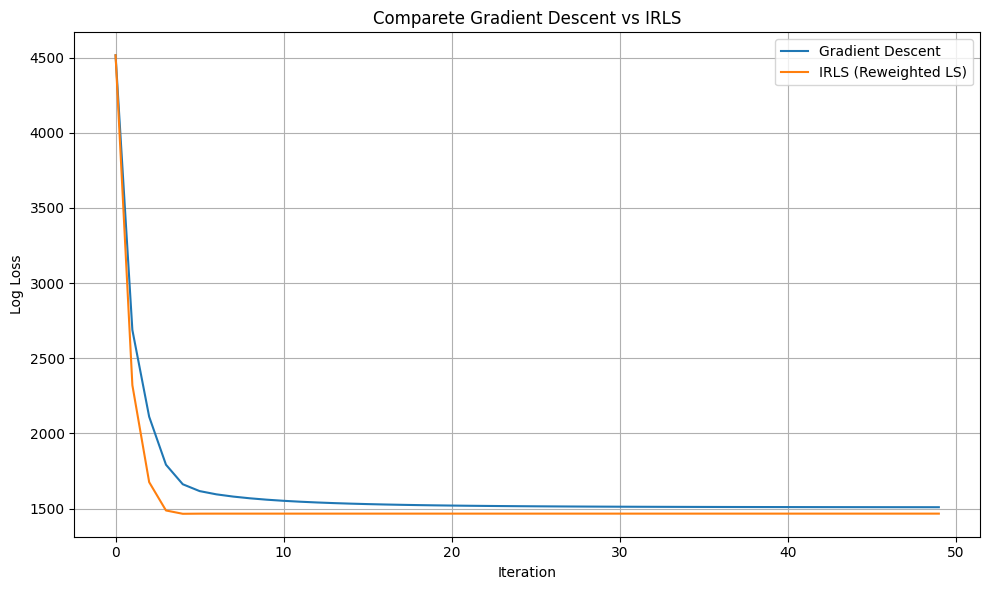

In [425]:
# Train the model
w_gd, loss_gd = LoR_gd(X_train_occ, y_train_occ, learning_rate=0.001, max_it=50)
w_irls, loss_irls = LoR_2(X_train_occ, y_train_occ, max_it=50)

# Plot the loss
plt.figure(figsize=(10, 6))
plt.plot(loss_gd, label="Gradient Descent")
plt.plot(range(0, len(loss_irls)), loss_irls, label="IRLS (Reweighted LS)")
plt.xlabel("Iteration")
plt.ylabel("Log Loss")
plt.title("Comparete Gradient Descent vs IRLS")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Build a function that predict the class of a point using a logistic regresion model and a treshold.

In [426]:
def pred_LoR(Xtest,w, threshold):
    # Probability predictions with sigmoid function
    probs = sigmoid(Xtest @ w)
    # Claification based on threshold
    return (probs >= threshold).astype(int)

Predict for the validation set of the occupacy dataset. Try different tresholds for classiffication and check the recall and precision for this different tresholds. 

In [427]:
def accuracy_score(y_true, y_pred):
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    return np.mean(y_true == y_pred)

def precision_score(y_true, y_pred):
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    TP = np.sum((y_pred == 1) & (y_true == 1))
    FP = np.sum((y_pred == 1) & (y_true == 0))
    return TP / (TP + FP + 1e-8)

def recall_score(y_true, y_pred):
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    TP = np.sum((y_pred == 1) & (y_true == 1))
    FN = np.sum((y_pred == 0) & (y_true == 1))
    return TP / (TP + FN + 1e-8)

In [428]:
thresholds = np.linspace(0.1, 0.9, 9)
precision_gd, recall_gd = [], []
precision_irls, recall_irls = [], []

for t in thresholds:
    y_pred_gd = pred_LoR(X_val_occ, w_gd, threshold=t)
    y_pred_irls = pred_LoR(X_val_occ, w_irls, threshold=t)

    precision_gd.append(precision_score(y_val_occ, y_pred_gd))
    recall_gd.append(recall_score(y_val_occ, y_pred_gd))

    precision_irls.append(precision_score(y_val_occ, y_pred_irls))
    recall_irls.append(recall_score(y_val_occ, y_pred_irls))

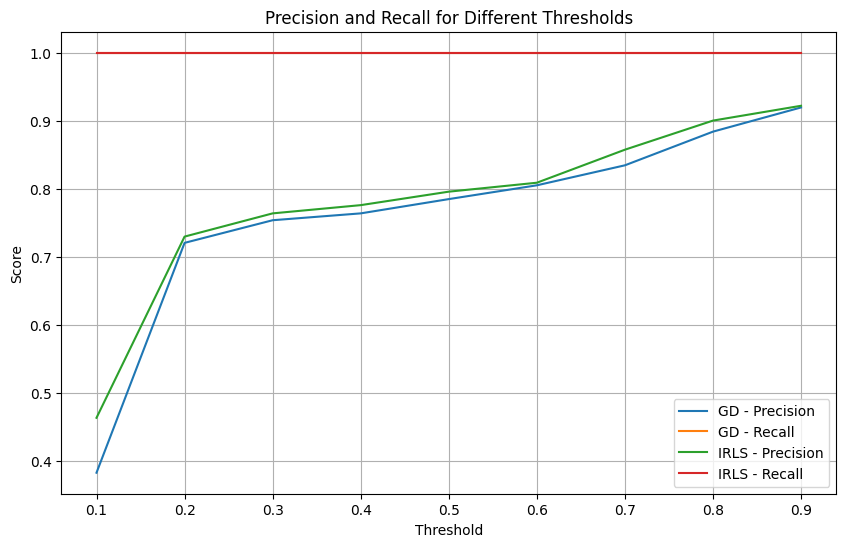

In [429]:
plt.figure(figsize=(10,6))
plt.plot(thresholds, precision_gd, label='GD - Precision')
plt.plot(thresholds, recall_gd, label='GD - Recall')
plt.plot(thresholds, precision_irls, label='IRLS - Precision')
plt.plot(thresholds, recall_irls, label='IRLS - Recall')
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision and Recall for Different Thresholds")
plt.legend()
plt.grid(True)
plt.show()

Train 2 new logistic regresion models, one for each training squeme, using a set of the union of validation and training. Choose the best treshold from your experiment in the last cell and predict for the points in the test set. Use a barplot to show the accuracy, recall and precision for both leaned logitic regression models.

In [430]:
X_trainval_occ = np.vstack([X_train_occ, X_val_occ])
y_trainval_occ = np.vstack([y_train_occ, y_val_occ])
best_threshold = thresholds[np.argmax(recall_gd)]
print("Best threshold", best_threshold)

w_gd_full, _ = LoR_gd(X_trainval_occ, y_trainval_occ, learning_rate=0.1, max_it=50)
w_irls_full, _ = LoR_2(X_trainval_occ, y_trainval_occ, max_it=50)


y_pred_test1_gd = pred_LoR(X_occupacy_test1_standar, w_gd_full, threshold=best_threshold)
y_pred_test1_irls = pred_LoR(X_occupacy_test1_standar, w_irls_full, threshold=best_threshold)

metrics_gd = {
    'Accuracy': accuracy_score(y_occupacy_test1, y_pred_test1_gd),
    'Precision': precision_score(y_occupacy_test1, y_pred_test1_gd),
    'Recall': recall_score(y_occupacy_test1, y_pred_test1_gd)
}

metrics_irls = {
    'Accuracy': accuracy_score(y_occupacy_test1, y_pred_test1_irls),
    'Precision': precision_score(y_occupacy_test1, y_pred_test1_irls),
    'Recall': recall_score(y_occupacy_test1, y_pred_test1_irls)
}


Best threshold 0.1
Logistic Regression - Gradient Descent
Final Logistic Regression - Gradient Descent
Logistic Regression - Reweighted Least Squares
Final Logistic Regression - Reweighted Least Squares


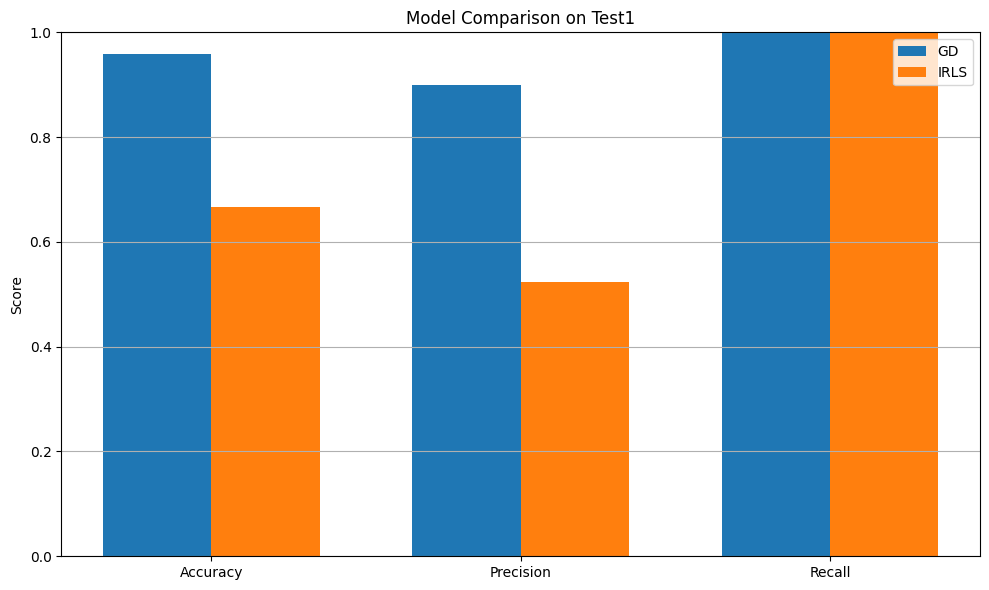

In [431]:
labels = list(metrics_gd.keys())
x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(10,6))
plt.bar(x - width/2, [metrics_gd[k] for k in labels], width, label='GD')
plt.bar(x + width/2, [metrics_irls[k] for k in labels], width, label='IRLS')

plt.ylabel('Score')
plt.title('Model Comparison on Test1')
plt.xticks(x, labels)
plt.ylim(0, 1)
plt.legend()
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

In [432]:
y_pred_test2_gd = pred_LoR(X_occupacy_test2_standar, w_gd_full, threshold=best_threshold)
y_pred_test2_irls = pred_LoR(X_occupacy_test2_standar, w_irls_full, threshold=best_threshold)

metrics_gd2 = {
    'Accuracy': accuracy_score(y_occupacy_test2, y_pred_test2_gd),
    'Precision': precision_score(y_occupacy_test2, y_pred_test2_gd),
    'Recall': recall_score(y_occupacy_test2, y_pred_test2_gd)
}

metrics_irls2 = {
    'Accuracy': accuracy_score(y_occupacy_test2, y_pred_test2_irls),
    'Precision': precision_score(y_occupacy_test2, y_pred_test2_irls),
    'Recall': recall_score(y_occupacy_test2, y_pred_test2_irls)
}


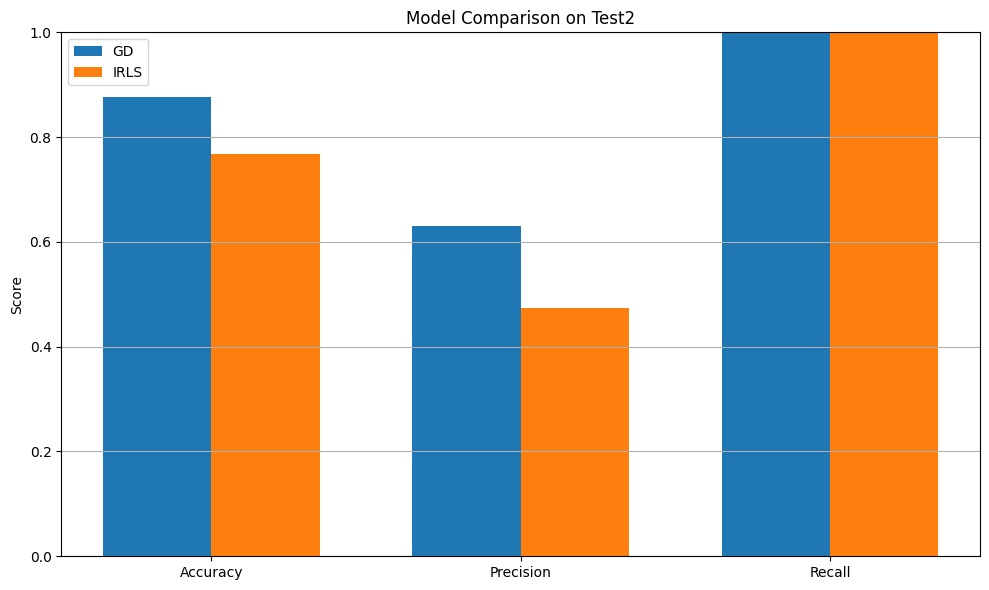

In [433]:
labels = list(metrics_gd.keys())
x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(10,6))
plt.bar(x - width/2, [metrics_gd2[k] for k in labels], width, label='GD')
plt.bar(x + width/2, [metrics_irls2[k] for k in labels], width, label='IRLS')

plt.ylabel('Score')
plt.title('Model Comparison on Test2')
plt.xticks(x, labels)
plt.ylim(0, 1)
plt.legend()
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()